<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ, 2025</b></h3>

<h3 style="text-align: center;"><b>Семинар. Детекция сгенерированных текстов </b></h3>


<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

На этом семинаре мы будем работать с данными из соревнования [Workshop-on-MGT-Detection-Task1 (COLING-2025)](https://github.com/mbzuai-nlp/COLING-2025-Workshop-on-MGT-Detection-Task1/?tab=readme-ov-file)

Этот датасет содержит тексты, написанные человеком, и текстовые генерации нескольких современных языковых моделей. Нам нужно решить задачу бинарной классификации текста на человеческий (real) и сгенерированный (fake).

Установим нужные библиотеки:

In [1]:
# !pip install transformers
# !pip install datasets

In [2]:
import math
import random
import pandas as pd
import numpy as np
import datasets
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy
from collections import Counter, defaultdict
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# Загрузка данных

In [3]:
atd_dataset = datasets.load_dataset("Jinyan1/COLING_2025_MGT_en")

In [4]:
atd_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'sub_source', 'lang', 'model', 'label', 'text'],
        num_rows: 610767
    })
    dev: Dataset({
        features: ['id', 'source', 'sub_source', 'lang', 'model', 'label', 'text'],
        num_rows: 261758
    })
})

Как видно, датасет имеет очень приличный размер. В дальнейшем, с целью ускорения вычислений, мы отфильтруем большую его часть и оставим генерации лишь нескольких моделей. Но сначала посмотрим на исходный список доменов и моделей-генераторов:

In [5]:
print("Список доменов:")
print(atd_dataset["train"].unique('sub_source'))
print()
print("Список моделей-генераторов:")
print(atd_dataset["train"].unique('model'))
print()
print("Модели-генераторы в train и dev подмножествах совпадают:")
print(set(atd_dataset["train"].unique('model')) == set(atd_dataset["dev"].unique('model')))

Список доменов:
['reddit', 'squad', 'yelp', 'xsum', 'wikipedia', 'reddit_eli5', 'wp', 'roct', 'outfox', 'wikihow', 'sci_gen', 'eli5', 'arxiv', 'cmv', 'tldr', 'peerread', 'hswag', 'finance', 'open_qa', 'imdb', 'wiki_csai', 'dialogsum', 'medicine', 'cnn', 'pubmed']

Список моделей-генераторов:
['llama3-8b', 'human', 'gpt-35', 'GLM130B', '65B', 'text-davinci-003', 'gpt4', 'gpt4o', '7B', 'opt_350m', 'gpt-3.5-turbo', 'cohere', 'davinci', 'mixtral-8x7b', 'gpt_j', 'opt_2.7b', 'flan_t5_small', 'flan_t5_xxl', 'bloomz', 't0_11b', 'opt_iml_max_1.3b', 'text-davinci-002', 'flan_t5_base', 'flan_t5_large', 'bloom_7b', 'opt_30b', 'opt_iml_30b', 'opt_1.3b', 'gpt_neox', 'dolly', '30B', 't0_3b', 'opt_6.7b', 'llama3-70b', 'gemma-7b-it', 'flan_t5_xl', '13B', 'gemma2-9b-it', 'opt_13b', 'dolly-v2-12b', 'opt_125m']

Модели-генераторы в train и dev подмножествах совпадают:
True


### Выбор доменов и моделей, генерации которых мы хотим оставить в нашем датасете

In [6]:
models_of_interest = {"train": ["human", "gpt-3.5-turbo", "gpt4", "llama3-8b", "llama3-70b"],
                      "dev": ["human", "mixtral-8x7b", "gpt4o", "gemma-7b-it", "gemma2-9b-it"]}
sources_of_interest = {"train": ["reddit"],
                       "dev": ["reddit", "wikipedia", "outfox"]}

splits = {"train": None, "dev": None}

for split in splits:
    # Фильтруем данные по интересующим моделям и источникам
    filtered_data = []
    for sample in atd_dataset[split]:
        if sample["model"] in models_of_interest[split] and sample["sub_source"] in sources_of_interest[split]:
            filtered_data.append(sample)
    
    # Создаем DataFrame
    df = pd.DataFrame(filtered_data)
    
    # Сэмплируем по n=min(1000, len(x)) примеров на каждую модель
    sampled_dfs = []
    for model in df['model'].unique():
        model_df = df[df['model'] == model]
        n_samples = min(1000, len(model_df))
        sampled_model_df = model_df.sample(n=n_samples, random_state=42)
        sampled_dfs.append(sampled_model_df)
    
    # Объединяем сэмплы всех моделей
    sampled_df = pd.concat(sampled_dfs, ignore_index=True)
    
    # Сохраняем обратно в Dataset
    splits[split] = datasets.Dataset.from_pandas(sampled_df)

Под моделью "human" в данном датасете подразумеваются тексты, написанные человеком. 😉

In [7]:
splits

{'train': Dataset({
     features: ['id', 'source', 'sub_source', 'lang', 'model', 'label', 'text'],
     num_rows: 5000
 }),
 'dev': Dataset({
     features: ['id', 'source', 'sub_source', 'lang', 'model', 'label', 'text'],
     num_rows: 5000
 })}

In [8]:
sampled_df.head()

,id,source,sub_source,lang,model,label,text
0,4e4c91ec-0395-4adb-a4a4-c1ca77506ba3,m4gt,outfox,en,mixtral-8x7b,1,Do you listen to other peoples opinions? Liste...
1,768dd223-0205-4671-aa94-fd2e7ce46d84,m4gt,reddit,en,mixtral-8x7b,1,"In the Gettysburg Address, when Abraham Lincol..."
2,e4db8f9f-630a-4161-9f95-20f3200e7fda,m4gt,reddit,en,mixtral-8x7b,1,"Well, a hedge fund is like a big savings accou..."
3,6642a803-0d72-43c2-a225-41a826884d10,m4gt,reddit,en,mixtral-8x7b,1,"Well, I don't really know too much about the R..."
4,6ec5be64-4c9e-4521-8369-e77b2d9a067b,m4gt,outfox,en,mixtral-8x7b,1,"In recent years, the debate over whether stude..."


Удостоверимся, что у нас осталось разумное количество генераций по каждой модели и домену

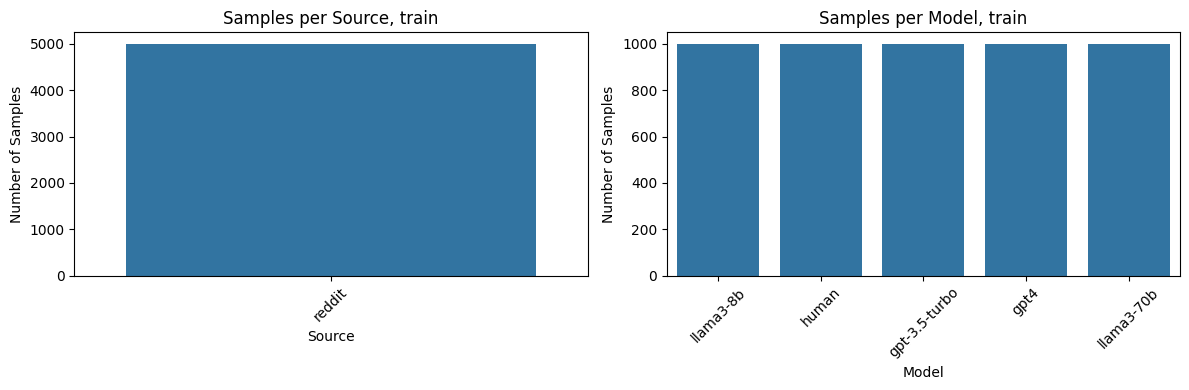

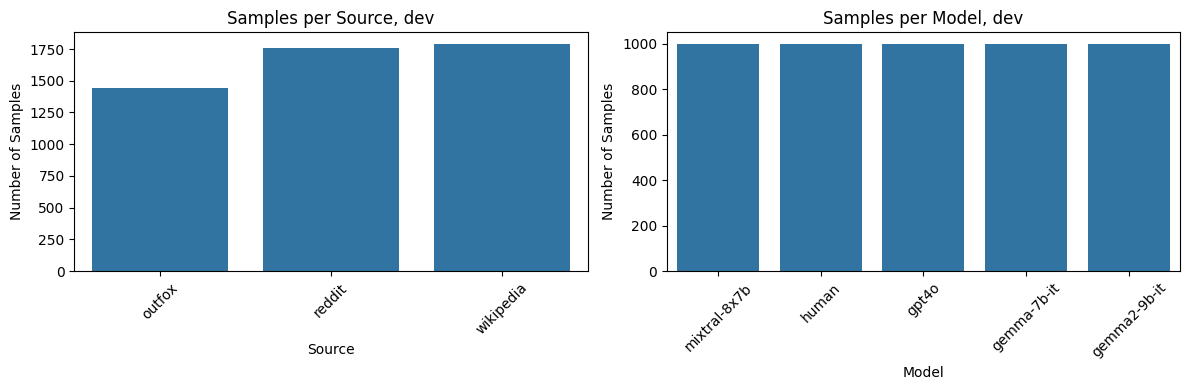

In [9]:
for split in splits:
    filtered_subset = splits[split]

    sources = [sample["sub_source"] for sample in filtered_subset]
    models = [sample["model"] for sample in filtered_subset]

    source_counts = Counter(sources)
    model_counts = Counter(models)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(x=list(source_counts.keys()), y=list(source_counts.values()), ax=axes[0])
    axes[0].set_title("Samples per Source, " + split)
    axes[0].set_xlabel("Source")
    axes[0].set_ylabel("Number of Samples")
    axes[0].tick_params(axis="x", rotation=45)

    sns.barplot(x=list(model_counts.keys()), y=list(model_counts.values()), ax=axes[1])
    axes[1].set_title("Samples per Model, " + split)
    axes[1].set_xlabel("Model")
    axes[1].set_ylabel("Number of Samples")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

# Загрузка модели gpt2

С помощью gpt2 мы будем считать перплексию и отличать сгенерированные тексты от человеческих. Можете поэкспериментировать с другими небольшими LLM (например, Phi-1.5) и посмотреть, как будет отличаться результат.

In [10]:
model_p = AutoModelForCausalLM.from_pretrained("gpt2", #"microsoft/phi-1.5",
                                             torch_dtype="auto",
                                             trust_remote_code=True,
                                             output_hidden_states=True
                                            )
tokenizer = AutoTokenizer.from_pretrained("gpt2", #"microsoft/phi-1.5",
                                          trust_remote_code=True
                                          )

c:\Users\pong\anaconda3\envs\ml\Lib\site-packages\transformers\generation\configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


In [11]:
device = "cuda"
model_p = model_p.to(device)

(Напоминание: чтобы использовать cuda-устройство из Google Colab, нужно подключить TPU или GPU в настройках среды выполнения)

# Вычисление средней перплексии по токенам

Напомним, что перплексия текста $x$ длины $t$ считается так:

$$PPL(x) = e^{-\frac{1}{t}\sum \log{p_\theta}(x_i|x_{< i})},$$

где сумма берется по всем отдельным токенам $x_i \in x$, а $\theta$ - параметры модели, перплексию которой мы считаем.

Логарифм перплексии, соответственно, равен negative log likelihood нашей последовательности токенов:

$$\log(PPL(x)) = NLL(x) = -\frac{1}{t}\sum \log{p_\theta}(x_i|x_{< i}).$$

Эту величину, в свою очередь, проще всего вычислять с помощью встроенной функции `ForCausalLMLoss` из библиотеки transformers - её реализацию можно посмотреть здесь: https://github.com/huggingface/transformers/blob/main/src/transformers/loss/loss_utils.py .

Как видно из исходного кода функции, $NLL$ считается через кросс-энтропию между двумя распределениями: одно - истинный текст, а другое - вероятности токенов, предсказанные моделью. В общем виде кросс-энтропия записывается так:

$$CrossEntropy(p, p_\theta) = - \sum_{x_i \in X} p (x_i) \log p_\theta(x_i),$$

где $p$ - истинное распределение над множеством возможных токенов $x_i \in X$, а $p_\theta$ - то, которое выдает модель. Однако, в нашем случае истинное "распределение" схлопнуто до one-hot векторов (вероятность истинного токена равна $1$, в то время как вероятности всех остальных токенов - $0$). Поэтому из всей суммы остается ненулевым только член с вероятностью $p_\theta$ единственного истинного токена, равного $x_i$:

$$\log p_\theta (x') = \log p_\theta (x_i | x_{<i}).$$

После усреднения этой величины по всем $x_i$ из текста как раз и получается $NLL$.

In [12]:
def calculate_perplexity(text, model, tokenizer, device):
    # Токенизация
    encodings = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    encodings = {k: v.to(device) for k, v in encodings.items()}

    # Вычисление mean negative log-likelihood (nll) per token
    # (стандартный loss для LLM в библиотеке transformers)
    input_ids = encodings["input_ids"]
    with torch.no_grad():
        outputs = model_p(**encodings, labels=input_ids)
        neg_log_likelihood = outputs.loss.item()

    perplexity = math.exp(neg_log_likelihood) # Перплексия вычисляется как e ^ nll
    return perplexity

In [13]:
perplexity_per_sample = defaultdict(list)

for split in splits: # train, dev
    for sample in tqdm(splits[split]):
        text = sample["text"]
        model_type = sample["model"]  # 'human' or model name
        sub_source = sample["sub_source"]

        try:
            ppl = calculate_perplexity(text, model_p, tokenizer, device)
            perplexity_per_sample[split].append({
                "perplexity": ppl,
                "model": model_type,
                "sub_source": sub_source
            })
        except Exception as e:
            print(f"Error processing sample: {e}")

100%|██████████| 5000/5000 [00:49<00:00, 100.41it/s]


In [14]:
df

,id,source,sub_source,lang,model,label,text
0,f3963cf1-5b1c-415f-b210-38da71f64244,m4gt,wikipedia,en,mixtral-8x7b,1,Zamyn-Üüd (Mongolian: Замын-Үüd) is a sum (dis...
1,2f61cc25-78e1-4e9e-83a3-72ecf9d09323,m4gt,outfox,en,human,0,Many places all over the world are starting to...
2,e1d5bb8d-94bd-46bf-976d-39a35b63009c,m4gt,reddit,en,human,0,"We really can't know for sure, with the except..."
3,3e412884-26ea-485b-95b9-49d77b6c6895,m4gt,wikipedia,en,human,0,The Town of Ellenboro is a town located in Gra...
4,c40170e4-cec5-4b7b-bd91-24d5a1fb0597,m4gt,wikipedia,en,human,0,Merville-Franceville-Plage () is a commune in ...
...,...,...,...,...,...,...,...
30263,71f75a1c-3db9-47e7-b1ab-ab142ae86f9b,m4gt,reddit,en,gpt4o,1,"Oh, that's a pretty interesting question! So, ..."
30264,01108e2e-49e6-4ea1-96f9-e4f2a9f2bf62,m4gt,outfox,en,mixtral-8x7b,1,Every planet is different and unique in their ...
30265,248aba5a-9137-4039-b5d9-377117d6c6e1,m4gt,outfox,en,human,0,The author has great supports about why we sho...
30266,89a89941-053a-4eaa-83b3-f9b396497f9f,m4gt,wikipedia,en,gemma-7b-it,1,## Sisters of the Infant Jesus\n\nThe Sisters ...


C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1577272028.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df, palette=palette)


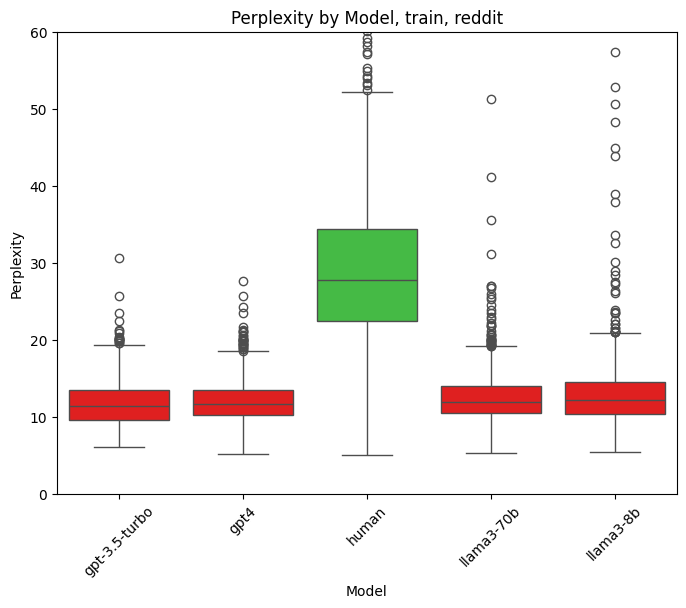

C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1577272028.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df, palette=palette)


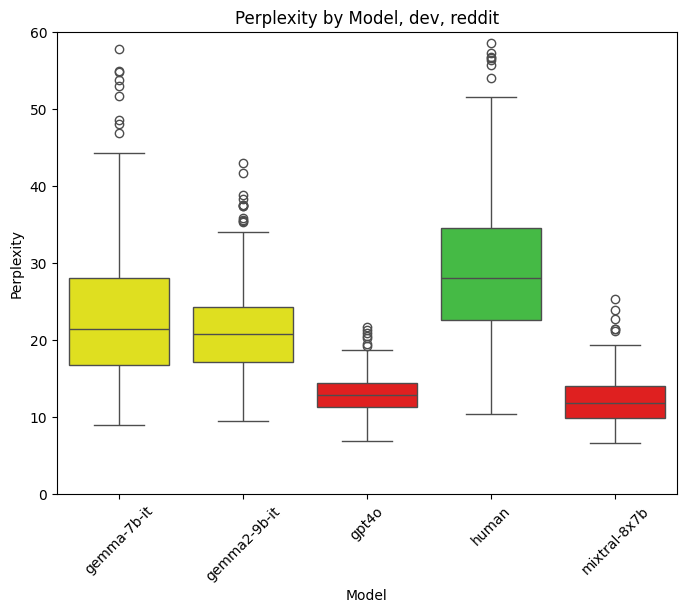

C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1577272028.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df, palette=palette)


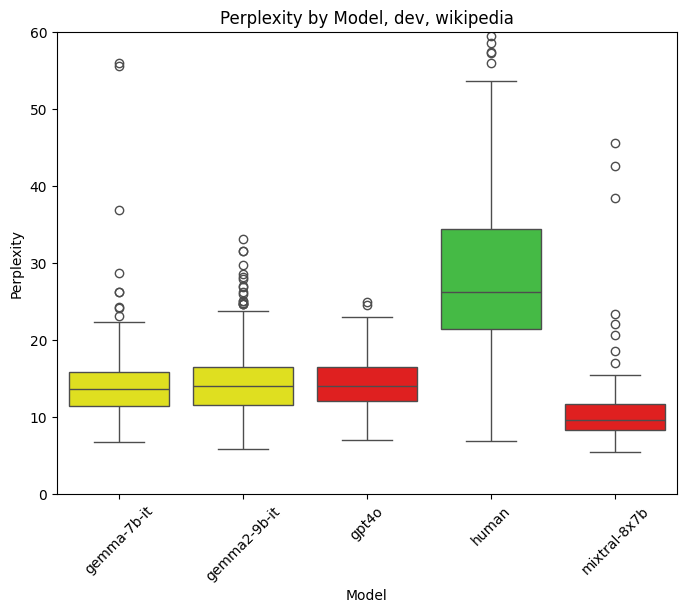

C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1577272028.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df, palette=palette)


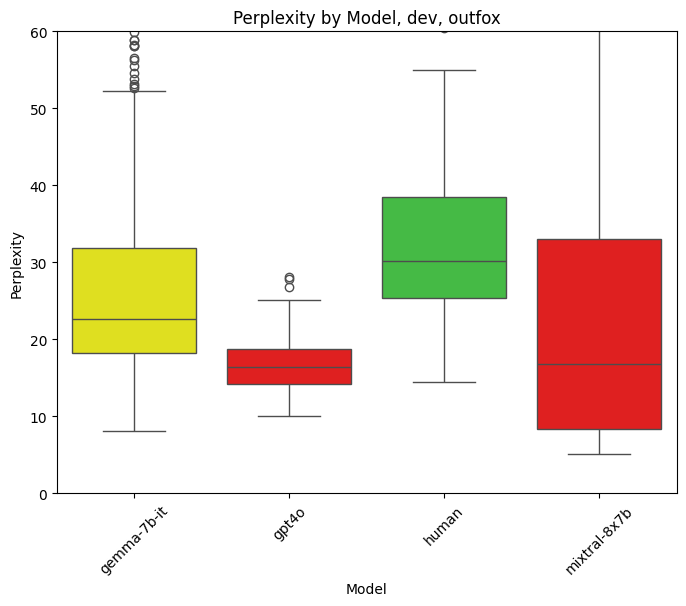

In [15]:
for split in splits: # train, dev
    for sub_source in sources_of_interest[split]: # wikipedia, reddit etc
        df = pd.DataFrame(perplexity_per_sample[split])
        df = df[df["sub_source"] == sub_source]
        df["model"] = pd.Categorical(df["model"], categories=sorted(df["model"].unique()), ordered=True)

        plt.figure(figsize=(8, 6))
        palette = {}
        for model in df["model"].unique():
            palette[model] = "red"
        palette["gemma-7b-it"] = "yellow"
        palette["gemma2-9b-it"] = "yellow"
        palette["human"] = "limegreen"
        sns.boxplot(x="model", y="perplexity", data=df, palette=palette)
        plt.title("Perplexity by Model, " + split + ", " + sub_source)
        plt.xlabel("Model")
        plt.ylabel("Perplexity")
        plt.ylim(0, 60)
        plt.tick_params(axis="x", rotation=45)
        plt.show()

Как видим, средняя перплексия у человеческих текстов существенно выше, чем у самых популярных моделей - например, моделей линеек gpt и llama. Тем не менее, у некоторых моделей и на некоторых доменах средняя перплексия сгенерированных текстов может быть близко к средней человеческой.

Проверим теперь, насколько хорошо пороговый классификатор, настроенный по нашему train set, классифицировать тексты из dev set:

In [16]:
len(perplexity_per_sample["dev"])

5000

In [17]:
train_data = pd.DataFrame(perplexity_per_sample["train"])
train_data["label"] = (train_data["model"] == "human").astype(int)

dev_data = pd.DataFrame(perplexity_per_sample["dev"])
dev_data["label"] = (dev_data["model"] == "human").astype(int)

# Классификация пороговым детектором

### Попробуем подбирать порог на тренировочном множестве наивным образом, выбрав метрику, которую мы желаем максимизировать.

В качестве такой метрики можно взять, например, F1. Обратите внимание на то, что если вместо F1 выбрать для максимизации accuracy, наш классификатор будет ошибочно записывать большинство человеческих текстов в сгенерированные (можете заменить f1_score на accuracy_score в коде внизу и убедиться в этом самостоятельно).

In [18]:
perplexities = train_data["perplexity"].values
labels = train_data["label"].values

thresholds = np.sort(perplexities)

best_threshold = None
best_f1 = 0

for threshold in thresholds:
    preds = (perplexities > threshold).astype(int)
    f1 = f1_score(labels, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best threshold: {best_threshold}, Train F1: {best_f1:.3f}")

Best threshold: 19.50911786162287, Train F1: 0.877


Посмотрим теперь, как будет вести себя полученный пороговый детектор на dev множестве.

In [19]:
dev_data['pred'] = (dev_data['perplexity'] > best_threshold).astype(int)

dev_accuracy = accuracy_score(dev_data['label'], dev_data['pred'])
dev_f1 = f1_score(dev_data['label'], dev_data['pred'])
print(f"Dev Accuracy (Threshold={best_threshold:.2f}): {dev_accuracy:.3f}")
print(f"Dev F1 (Threshold={best_threshold:.2f}): {dev_f1:.3f}")

Dev Accuracy (Threshold=19.51): 0.721
Dev F1 (Threshold=19.51): 0.550


### Сравним качество детекции по моделям

In [20]:
model_accuracy = dev_data.groupby('model').apply(
    lambda x: accuracy_score(x['label'], x['pred'])
)

print("\nPer-Model Accuracy:")
print(model_accuracy.sort_values())


Per-Model Accuracy:
model
gemma-7b-it     0.500
gemma2-9b-it    0.649
mixtral-8x7b    0.679
human           0.851
gpt4o           0.928
dtype: float64


In [21]:
dev_data['pred'] = (dev_data['perplexity'] > best_threshold).astype(int)

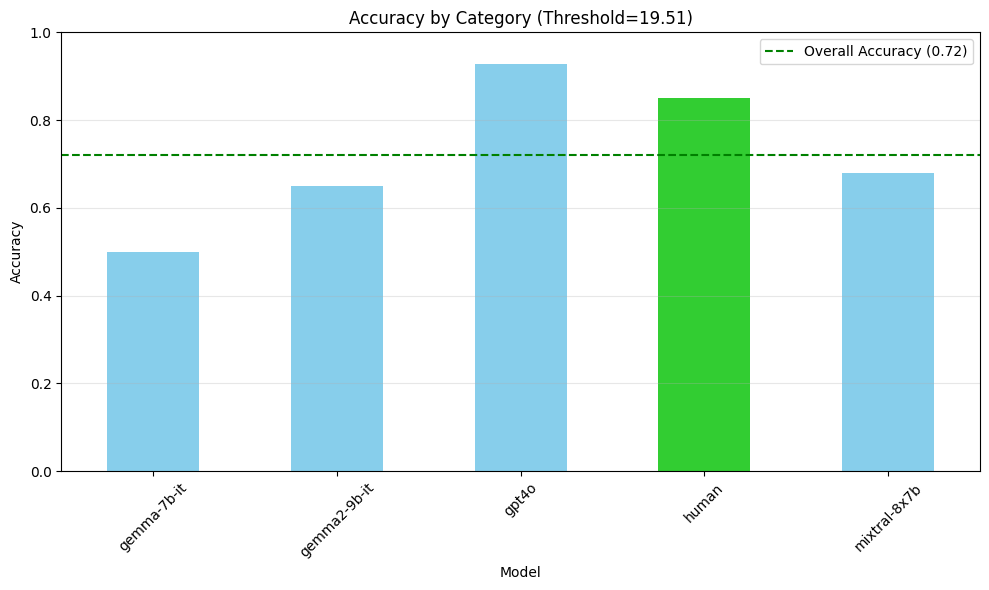

In [22]:
plt.figure(figsize=(10, 6))

# Create colors list - ensure 'human' gets red regardless of sorting
colors = ['limegreen' if 'human' in str(idx).lower() else 'skyblue' for idx in model_accuracy.index]

# Plot with corrected colors
model_accuracy.plot(kind='bar', color=colors)

plt.axhline(y=dev_accuracy, color='green', linestyle='--', label=f'Overall Accuracy ({dev_accuracy:.2f})')
plt.title(f"Accuracy by Category (Threshold={best_threshold:.2f})")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Как видим, наш классификатор хорошо детектирует популярные модели, но плохо детектирует модели типа gemma. Также он ошибочно отнес часть человеческих текстов к категории машинно-сгенерированных. В реальных детекторах стараются минимизировать вероятность подобных ложных срабатываний.

# Атака на пороговый детектор

Представим теперь, что мы хотим обмануть пороговый детектор, выдав сгенерированные тексты за написанные человеком. Один из возможных вариантов такой атаки - замена части букв в тексте на их омоглифы. Омоглифы — это графически одинаковые или похожие друг на друга знаки, имеющие разное значение; например, омоглифами являются английская "о" и русская "о".

Так, если в английском слове английскую "о" заменить на русский аналог, для человека такое слово визуально не изменится, но перплексия gpt-2 (да и других моделей) на нем резко возрастет, так как для модели слово начнет выглядеть как совершенно другое, малознакомое и маловероятное сочетание токенов. Точно также можно заменять и любые другие символы на визуально похожие, чем мы сейчас и займемся.

### Загрузим список омоглифов из репозитория https://github.com/codebox/homoglyph/

In [23]:
# !wget https://raw.githubusercontent.com/codebox/homoglyph/refs/heads/master/raw_data/chars.txt

In [24]:
import urllib.request
import os

# Создаем папку, если ее нет
os.makedirs('content', exist_ok=True)

# Путь к файлу
file_path = 'content/chars.txt'

# Проверяем, существует ли файл
if not os.path.exists(file_path):
    url = 'https://raw.githubusercontent.com/codebox/homoglyph/refs/heads/master/raw_content/chars.txt'
    urllib.request.urlretrieve(url, file_path)
    print(f'Файл сохранен в {file_path}')
else:
    print(f'Файл уже существует в {file_path}')

Файл уже существует в content/chars.txt


In [25]:
homoglyph_dict = {}
max_homoglyphs_amount = 5

with open("content/chars.txt", "r") as f:
    for line in f:
        homoglyph_dict[line[0]] = line[1 : max_homoglyphs_amount+1].strip()

### Заменим символы из каждого искуственно сгенерированного текста в dev на их омоглифы с вероятностью 2%

(при условии, что символ есть в словаре)

In [26]:
def homoglyph_attack(text, p=0.5):
    homoglyph_text = []
    for c in text:
        if c in homoglyph_dict and len(homoglyph_dict[c]) >= 1 and random.random() < p:
            new_c = random.choice(list(homoglyph_dict[c]))
        else:
            new_c = c
        homoglyph_text.append(new_c)
    return "".join(homoglyph_text)

In [27]:
attacked_dev = deepcopy(splits["dev"])
attacked_text = []

for i in tqdm(range(len(attacked_dev))):
    sample = attacked_dev[i]
    if sample["model"] != "human":
        attacked_text.append(homoglyph_attack(sample["text"], p=0.02))
    else:
        attacked_text.append(sample["text"])

100%|██████████| 5000/5000 [00:01<00:00, 4641.17it/s]


In [28]:
len(attacked_text), len(attacked_dev)

(5000, 5000)

In [29]:
attacked_dev = attacked_dev.remove_columns("text")
attacked_dev = attacked_dev.add_column("text", attacked_text)

### Посчитаем перплексию на текстах, к которым применена наша атака

In [30]:
splits["attacked_dev"] = attacked_dev
split = "attacked_dev"

for sample in tqdm(splits[split]):
    text = sample["text"]
    model_type = sample["model"]  # 'human' or model name
    sub_source = sample["sub_source"]

    ppl = calculate_perplexity(text, model_p, tokenizer, device)
    perplexity_per_sample[split].append({
        "perplexity": ppl,
        "model": model_type,
        "sub_source": sub_source
    })

100%|██████████| 5000/5000 [00:49<00:00, 101.39it/s]


C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1615238298.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df_dev, palette=palette, ax=axes[0])  # Plot on the left subplot
C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1615238298.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df_attacked, palette=palette, ax=axes[1])  # Plot on the right subplot


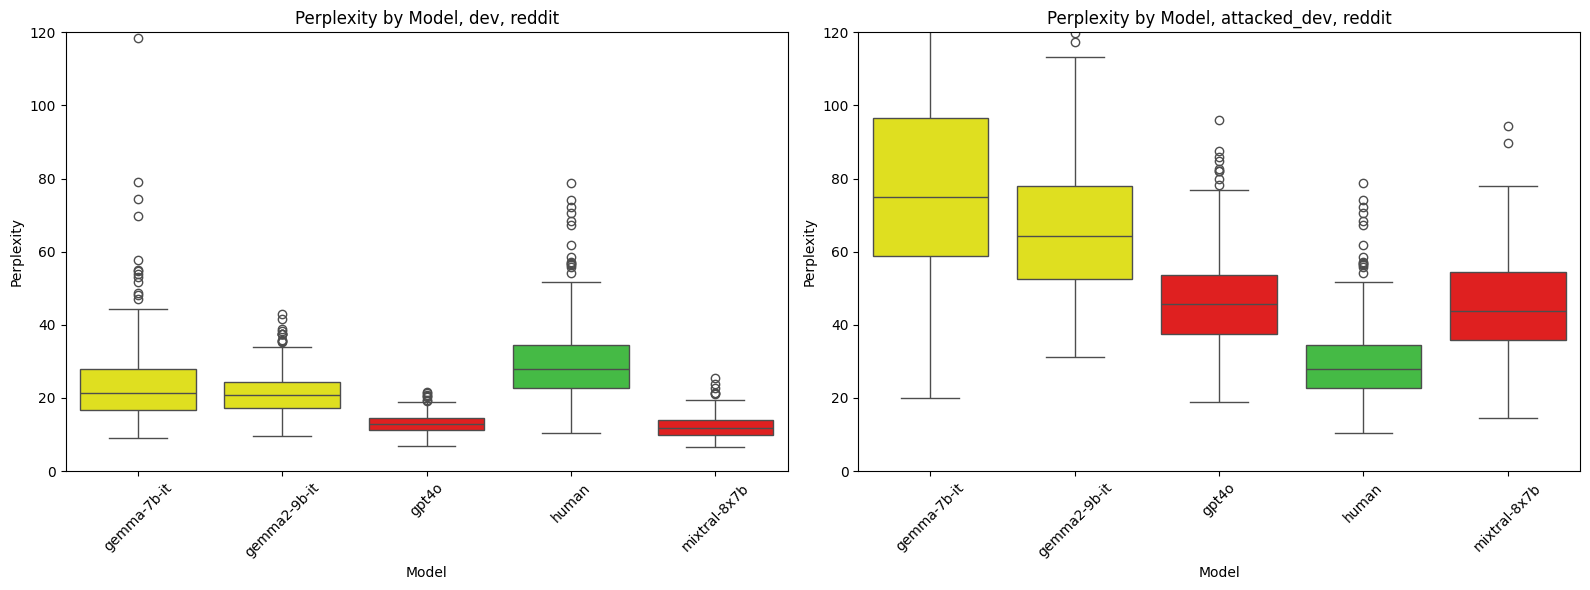

C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1615238298.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df_dev, palette=palette, ax=axes[0])  # Plot on the left subplot
C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1615238298.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df_attacked, palette=palette, ax=axes[1])  # Plot on the right subplot


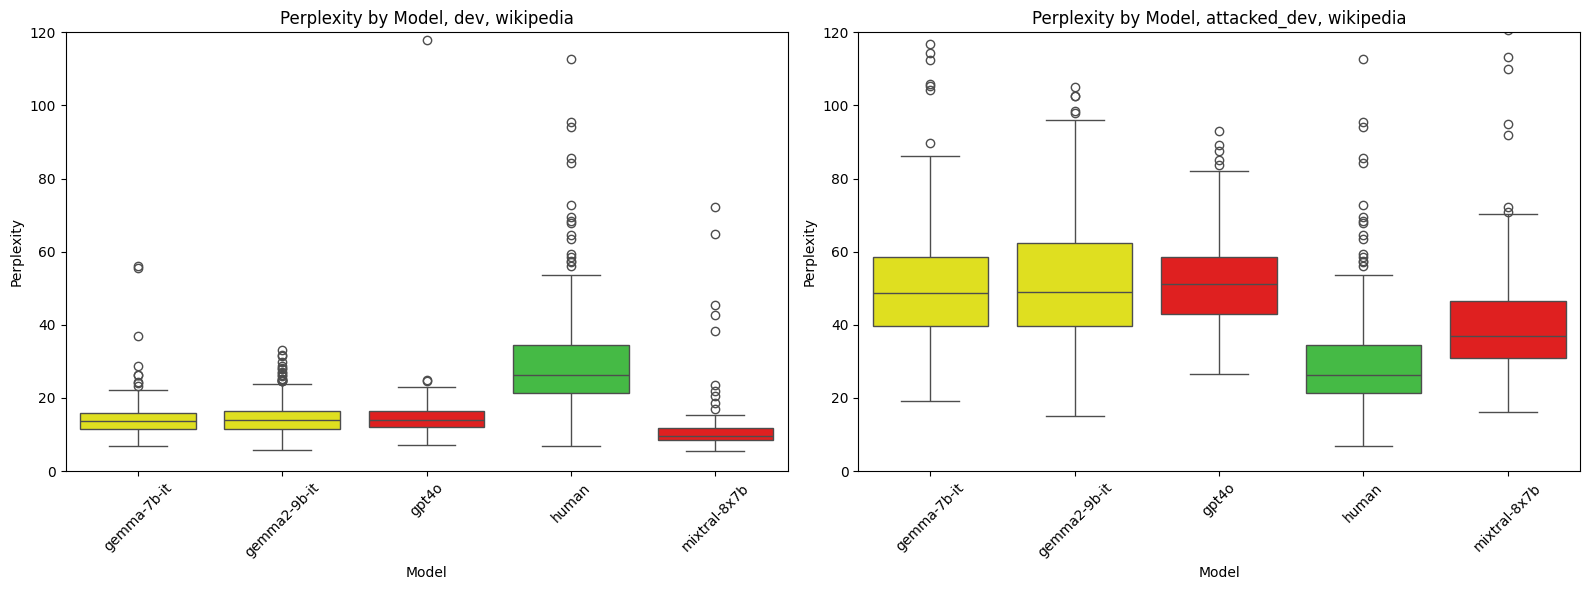

C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1615238298.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df_dev, palette=palette, ax=axes[0])  # Plot on the left subplot
C:\Users\pong\AppData\Local\Temp\ipykernel_3848\1615238298.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model", y="perplexity", data=df_attacked, palette=palette, ax=axes[1])  # Plot on the right subplot


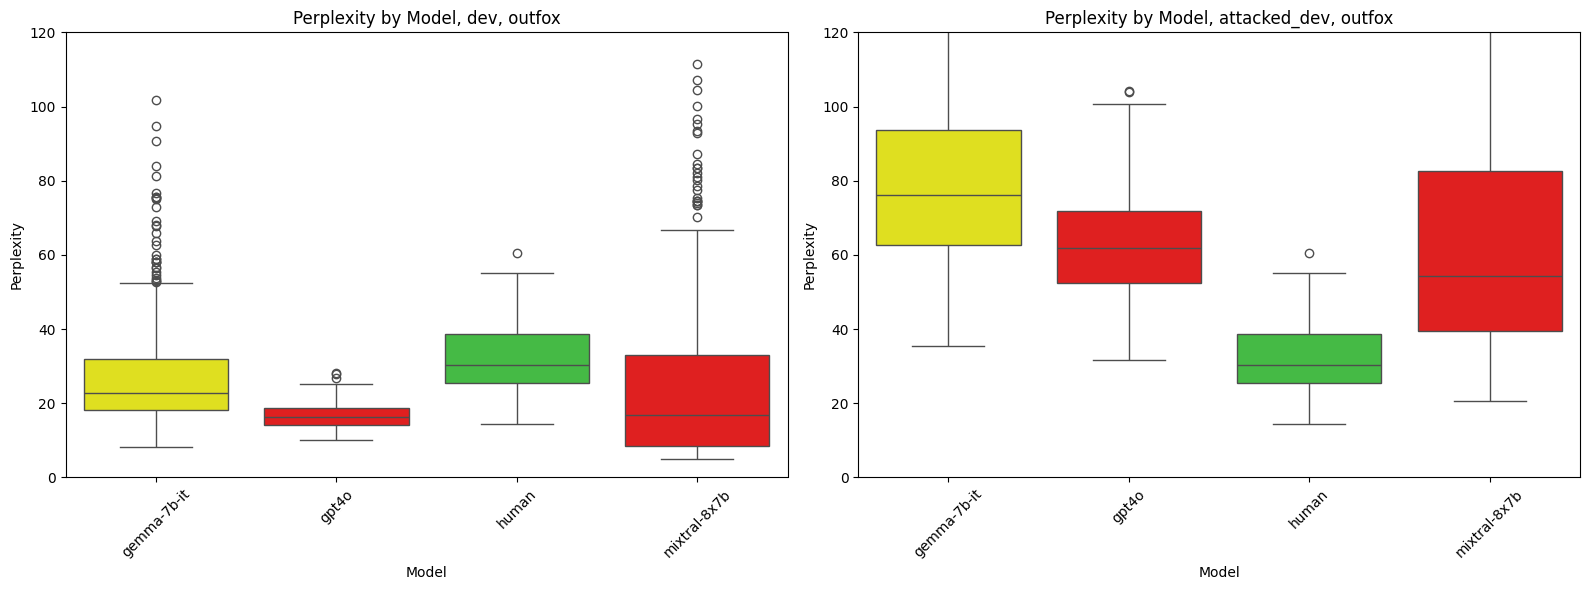

In [31]:
sources_of_interest["attacked_dev"] = sources_of_interest["dev"]

for sub_source in sources_of_interest["dev"]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Create 2 subplots

    # Boxplot for 'dev' data
    df_dev = pd.DataFrame(perplexity_per_sample["dev"])
    df_dev = df_dev[df_dev["sub_source"] == sub_source]
    df_dev["model"] = pd.Categorical(df_dev["model"], categories=sorted(df_dev["model"].unique()), ordered=True)
    palette = {}
    for model in df_dev["model"].unique():
        palette[model] = "red"
    palette["gemma-7b-it"] = "yellow"
    palette["gemma2-9b-it"] = "yellow"
    palette["human"] = "limegreen"
    sns.boxplot(x="model", y="perplexity", data=df_dev, palette=palette, ax=axes[0])  # Plot on the left subplot
    axes[0].set_title("Perplexity by Model, dev, " + sub_source)
    axes[0].set_xlabel("Model")
    axes[0].set_ylabel("Perplexity")
    axes[0].set_ylim(0, 120)
    axes[0].tick_params(axis="x", rotation=45)

    # Boxplot for 'attacked_dev' data
    df_attacked = pd.DataFrame(perplexity_per_sample["attacked_dev"])
    df_attacked = df_attacked[df_attacked["sub_source"] == sub_source]
    df_attacked["model"] = pd.Categorical(df_attacked["model"], categories=sorted(df_attacked["model"].unique()), ordered=True)
    sns.boxplot(x="model", y="perplexity", data=df_attacked, palette=palette, ax=axes[1])  # Plot on the right subplot
    axes[1].set_title("Perplexity by Model, attacked_dev, " + sub_source)
    axes[1].set_xlabel("Model")
    axes[1].set_ylabel("Perplexity")
    axes[1].set_ylim(0, 120)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

Как видим, достаточно было заменить всего 2% символов на гомоглифы, чтобы перплексия наших сгенерированных текстов резко возросла. При этом внешний вид текстов поменялся совсем немного, и они остались человеко-читаемыми:

In [32]:
attacked_dev[0]

{'id': '4e4c91ec-0395-4adb-a4a4-c1ca77506ba3',
 'source': 'm4gt',
 'sub_source': 'outfox',
 'lang': 'en',
 'model': 'mixtral-8x7b',
 'label': 1,
 'text': 'Do you listen to other peoples opinioռs? Listening to other peoples opinions\xa0can be a good or bad thing you decide  I think that when you listen to other peoples opinions on ƽomething that could get you in trouᏏle is a good thing if you were going to do something bad and ƽomeone close to you says "dont do it" you should not do it  The only way i would personally do something is through my gut instinct.\n\nIf your gut is telling you to do something or push towardｓ something i would do it. No matteᴦ what go ɯith your gut. If you dont go with your gut you will never know what could have happened if you went with your gut instead you listened to other people. From my own experience i didnt go with my gut one time and i messed everything up with this one person. Know matter what the oꞟtᴄome was at least you can say you went with your g

In [33]:
attacked_dev[1000]

{'id': 'da7ff283-e72c-420e-a789-0d56c41a1a32',
 'source': 'm4gt',
 'sub_source': 'reddit',
 'lang': 'en',
 'model': 'human',
 'label': 0,
 'text': 'The bank is predicting that interest rates will rise over the next five years. Since rates are historically low that is a safe bet by any standard but the question for them is how much and how soon. The reason this is important to them is that they make money on the spread - the difference between what they pay in interest to people who deposit money and people like you that are borrowing money. The problem arises when they have to offer you what is essentially a future interest rate for five years from now as that is a standard term in a large loan such as a mortgage. Despite the sophistication of banks it is exceedingly difficult to predict the economy five years from now. Look at the way things were five years ago as compared to now to try understand the complexities of this type of prognostication.\nYour best interest (no pun) is served

### Посмотрим, как произошедшее повлияло на наш детектор

In [34]:
attacked_dev_data = pd.DataFrame(perplexity_per_sample["attacked_dev"])

attacked_dev_data['label'] = (attacked_dev_data['model'] == 'human').astype(int)
attacked_dev_data['pred'] = (attacked_dev_data['perplexity'] > best_threshold).astype(int)

attacked_dev_accuracy = accuracy_score(attacked_dev_data['label'], attacked_dev_data['pred'])
attacked_dev_f1 = f1_score(attacked_dev_data['label'], attacked_dev_data['pred'], zero_division=0)
print(f"Dev Accuracy (Threshold={best_threshold:.2f}): {attacked_dev_accuracy:.3f}")
print(f"Dev F1 (Threshold={best_threshold:.2f}): {attacked_dev_f1:.3f}")

model_accuracy = attacked_dev_data.groupby('model').apply(
    lambda x: accuracy_score(x['label'], x['pred'])
)

print("\nPer-Model Accuracy:")
print(model_accuracy.sort_values())

Dev Accuracy (Threshold=19.51): 0.172
Dev F1 (Threshold=19.51): 0.291

Per-Model Accuracy:
model
gemma-7b-it     0.001
gpt4o           0.001
gemma2-9b-it    0.003
mixtral-8x7b    0.005
human           0.851
dtype: float64


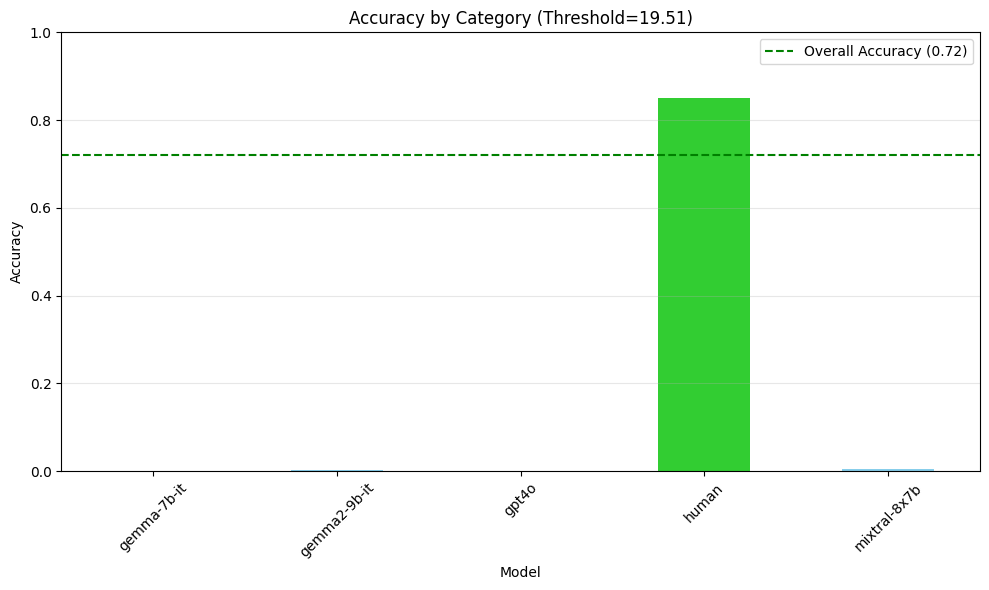

In [35]:
plt.figure(figsize=(10, 6))

# Create colors list - ensure 'human' gets red regardless of sorting
colors = ['limegreen' if 'human' in str(idx).lower() else 'skyblue' for idx in model_accuracy.index]

# Plot with corrected colors
model_accuracy.plot(kind='bar', color=colors)

plt.axhline(y=dev_accuracy, color='green', linestyle='--', label=f'Overall Accuracy ({dev_accuracy:.2f})')
plt.title(f"Accuracy by Category (Threshold={best_threshold:.2f})")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Как видим, качество детекции сгенерированных текстов упало настолько, что детектор стал практически бесполезен.